In [1]:
from bs4 import BeautifulSoup
import requests

In [2]:
url = 'https://www.scrapethissite.com/pages/forms/?page_num=3'

In [3]:
page = requests.get(url)

In [4]:
soup = BeautifulSoup(page.text, 'html')

In [5]:
print(soup)

<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="utf-8"/>
<title>Hockey Teams: Forms, Searching and Pagination | Scrape This Site | A public sandbox for learning web scraping</title>
<link href="/static/images/scraper-icon.png" rel="icon" type="image/png"/>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<meta content="Browse through a database of NHL team stats since 1990. Practice building a scraper that handles common website interface components." name="description"/>
<link crossorigin="anonymous" href="https://maxcdn.bootstrapcdn.com/bootstrap/3.3.5/css/bootstrap.min.css" integrity="sha256-MfvZlkHCEqatNoGiOXveE8FIwMzZg4W85qfrfIFBfYc= sha512-dTfge/zgoMYpP7QbHy4gWMEGsbsdZeCXz7irItjcC3sPUFtf0kuFbDz/ixG7ArTxmDjLXDmezHubeNikyKGVyQ==" rel="stylesheet"/>
<link href="https://fonts.googleapis.com/css?family=Lato:400,700" rel="stylesheet" type="text/css"/>
<link href="/static/css/styles.css" rel="stylesheet" type="text/css"/>
<meta content="noindex" name="robot

In [9]:
soup.find('table')

<table class="table">
<tr>
<th>
                            Team Name
                        </th>
<th>
                            Year
                        </th>
<th>
                            Wins
                        </th>
<th>
                            Losses
                        </th>
<th>
                            OT Losses
                        </th>
<th>
                            Win %
                        </th>
<th>
                            Goals For (GF)
                        </th>
<th>
                            Goals Against (GA)
                        </th>
<th>
                            + / -
                        </th>
</tr>
<tr class="team">
<td class="name">
                            Los Angeles Kings
                        </td>
<td class="year">
                            1992
                        </td>
<td class="wins">
                            39
                        </td>
<td class="losses">
                         

In [11]:
soup.find('table', class_ ='table')

<table class="table">
<tr>
<th>
                            Team Name
                        </th>
<th>
                            Year
                        </th>
<th>
                            Wins
                        </th>
<th>
                            Losses
                        </th>
<th>
                            OT Losses
                        </th>
<th>
                            Win %
                        </th>
<th>
                            Goals For (GF)
                        </th>
<th>
                            Goals Against (GA)
                        </th>
<th>
                            + / -
                        </th>
</tr>
<tr class="team">
<td class="name">
                            Los Angeles Kings
                        </td>
<td class="year">
                            1992
                        </td>
<td class="wins">
                            39
                        </td>
<td class="losses">
                         

In [12]:
table = soup.find('table')

In [13]:
print(table)

<table class="table">
<tr>
<th>
                            Team Name
                        </th>
<th>
                            Year
                        </th>
<th>
                            Wins
                        </th>
<th>
                            Losses
                        </th>
<th>
                            OT Losses
                        </th>
<th>
                            Win %
                        </th>
<th>
                            Goals For (GF)
                        </th>
<th>
                            Goals Against (GA)
                        </th>
<th>
                            + / -
                        </th>
</tr>
<tr class="team">
<td class="name">
                            Los Angeles Kings
                        </td>
<td class="year">
                            1992
                        </td>
<td class="wins">
                            39
                        </td>
<td class="losses">
                         

In [14]:
hockey_team = table.find_all('th')

In [15]:
hockey_team

[<th>
                             Team Name
                         </th>,
 <th>
                             Year
                         </th>,
 <th>
                             Wins
                         </th>,
 <th>
                             Losses
                         </th>,
 <th>
                             OT Losses
                         </th>,
 <th>
                             Win %
                         </th>,
 <th>
                             Goals For (GF)
                         </th>,
 <th>
                             Goals Against (GA)
                         </th>,
 <th>
                             + / -
                         </th>]

In [16]:
hockey_team_table = [team.text.strip() for team in hockey_team]

print(hockey_team_table)

['Team Name', 'Year', 'Wins', 'Losses', 'OT Losses', 'Win %', 'Goals For (GF)', 'Goals Against (GA)', '+ / -']


In [17]:
import pandas as pd

In [18]:
df = pd.DataFrame(columns = hockey_team_table)

df

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -


In [19]:
column_data = table.find_all('tr')

In [20]:
for row in column_data[1:]:
    row_data = row.find_all('td')
    individual_row_data = [data.text.strip() for data in row_data]
    
    length = len(df)
    df.loc[length] =  individual_row_data

In [21]:
df

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Los Angeles Kings,1992,39,35,,0.464,338,340,-2
1,Minnesota North Stars,1992,36,38,,0.429,272,293,-21
2,Montreal Canadiens,1992,48,30,,0.571,326,280,46
3,New Jersey Devils,1992,40,37,,0.476,308,299,9
4,New York Islanders,1992,40,37,,0.476,335,297,38
5,New York Rangers,1992,34,39,,0.405,304,308,-4
6,Ottawa Senators,1992,10,70,,0.119,202,395,-193
7,Philadelphia Flyers,1992,36,37,,0.429,319,319,0
8,Pittsburgh Penguins,1992,56,21,,0.667,367,268,99
9,Quebec Nordiques,1992,47,27,,0.56,351,300,51


In [22]:
df.to_csv(r'C:\Users\Seun Adesina\OneDrive\Documents\Webscraping\Hockey.csv', index = False)

CHARTS DEVELOPMENT

In [3]:
import pandas as pd

In [18]:
df = pd.read_csv(r"C:\Users\Seun Adesina\OneDrive\Documents\Webscraping\Hockey.csv")

In [19]:
df

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Los Angeles Kings,1992,39,35,NaN,0.464,338,340,-2
1,Minnesota North Stars,1992,36,38,NaN,0.429,272,293,-21
2,Montreal Canadiens,1992,48,30,NaN,0.571,326,280,46
3,New Jersey Devils,1992,40,37,NaN,0.476,308,299,9
4,New York Islanders,1992,40,37,NaN,0.476,335,297,38
5,New York Rangers,1992,34,39,NaN,0.405,304,308,-4
6,Ottawa Senators,1992,10,70,NaN,0.119,202,395,-193
7,Philadelphia Flyers,1992,36,37,NaN,0.429,319,319,0
8,Pittsburgh Penguins,1992,56,21,NaN,0.667,367,268,99
9,Quebec Nordiques,1992,47,27,NaN,0.560,351,300,51


In [20]:
df.head()

,Team Name,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
0,Los Angeles Kings,1992,39,35,NaN,0.464,338,340,-2
1,Minnesota North Stars,1992,36,38,NaN,0.429,272,293,-21
2,Montreal Canadiens,1992,48,30,NaN,0.571,326,280,46
3,New Jersey Devils,1992,40,37,NaN,0.476,308,299,9
4,New York Islanders,1992,40,37,NaN,0.476,335,297,38


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Team Name           25 non-null     object 
 1   Year                25 non-null     int64  
 2   Wins                25 non-null     int64  
 3   Losses              25 non-null     int64  
 4   OT Losses           0 non-null      float64
 5   Win %               25 non-null     float64
 6   Goals For (GF)      25 non-null     int64  
 7   Goals Against (GA)  25 non-null     int64  
 8   + / -               25 non-null     int64  
dtypes: float64(2), int64(6), object(1)
memory usage: 1.9+ KB


In [22]:
df.describe()

,Year,Wins,Losses,OT Losses,Win %,Goals For (GF),Goals Against (GA),+ / -
count,25.000000,25.000000,25.000000,0.0,25.000000,25.000000,25.000000,25.000000
mean,1992.320000,37.680000,37.480000,NaN,0.448640,296.280000,292.400000,3.880000
std,0.476095,10.675986,12.062753,NaN,0.127105,44.167786,45.182039,72.149913
min,1992.000000,10.000000,21.000000,NaN,0.119000,202.000000,218.000000,-196.000000
25%,1992.000000,36.000000,29.000000,NaN,0.429000,272.000000,265.000000,-4.000000
50%,1992.000000,40.000000,36.000000,NaN,0.476000,302.000000,286.000000,14.000000
75%,1993.000000,43.000000,38.000000,NaN,0.512000,326.000000,308.000000,46.000000
max,1993.000000,56.000000,71.000000,NaN,0.667000,367.000000,414.000000,99.000000


In [23]:
df.columns = (
    df.columns
    .str.strip()
    .str.replace(' ', '_')
    .str.replace('/', '_')
    .str.replace('+', 'plus')
    .str.replace('-', 'minus')
)

df.columns

Index(['Team_Name', 'Year', 'Wins', 'Losses', 'OT_Losses', 'Win_%',
       'Goals_For_(GF)', 'Goals_Against_(GA)', 'plus___minus'],
      dtype='object')

In [24]:
df = df.rename(columns={
    'Team_Name': 'Team',
    'Win_%': 'Win_Pct',
    'Goals_For_(GF)': 'GF',
    'Goals_Against_(GA)': 'GA',
    'plus___minus': 'Goal_Diff'
})

In [25]:
df.columns

Index(['Team', 'Year', 'Wins', 'Losses', 'OT_Losses', 'Win_Pct', 'GF', 'GA',
       'Goal_Diff'],
      dtype='object')

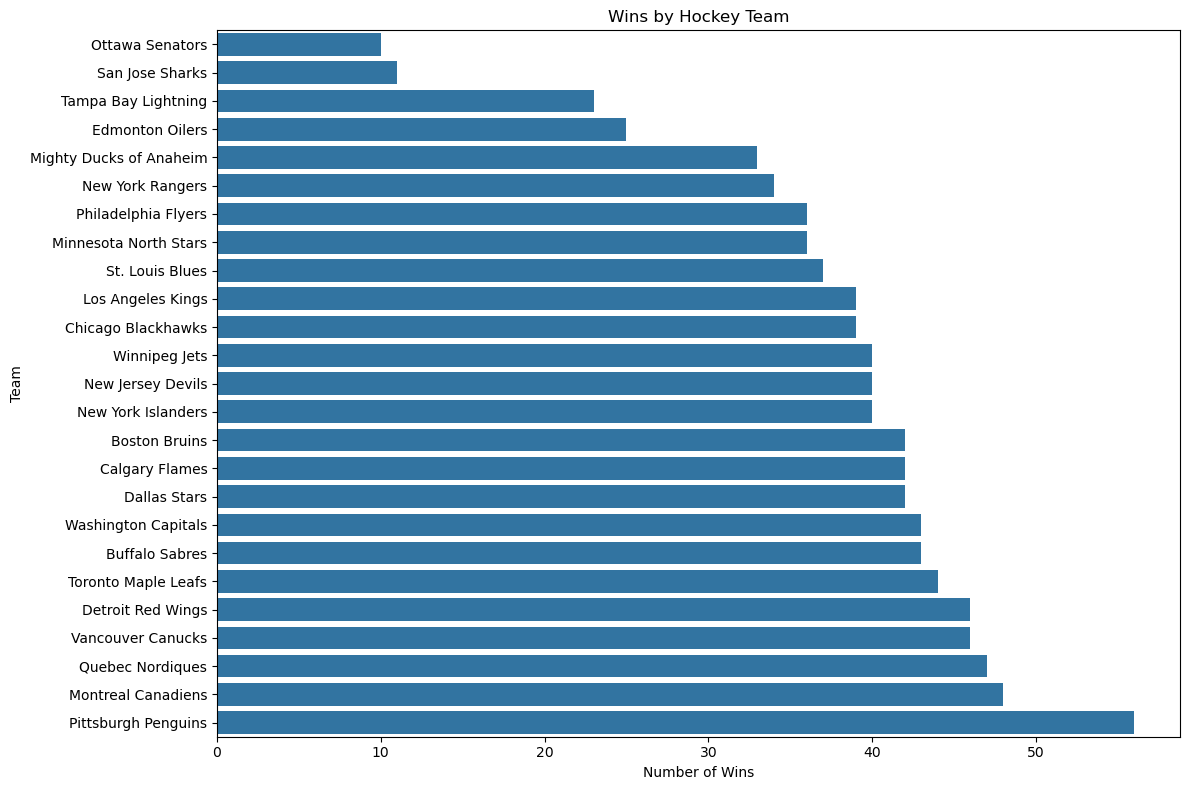

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

plot_df = df.sort_values('Wins')

sns.barplot(
    data=plot_df,
    x='Wins',
    y='Team'
)

plt.title('Wins by Hockey Team')
plt.xlabel('Number of Wins')
plt.ylabel('Team')

plt.tight_layout()
plt.show()

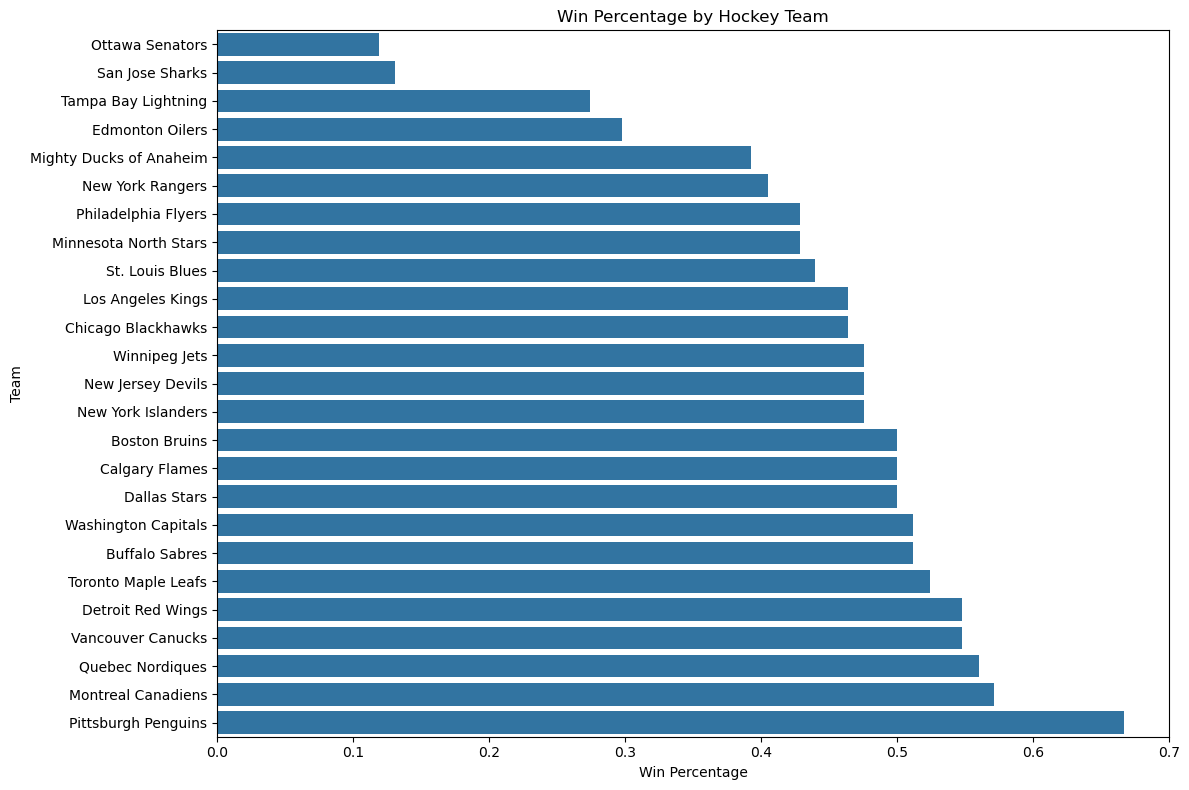

In [27]:
plt.figure(figsize=(12, 8))

plot_df = df.sort_values('Win_Pct')

sns.barplot(
    data=plot_df,
    x='Win_Pct',
    y='Team'
)

plt.title('Win Percentage by Hockey Team')
plt.xlabel('Win Percentage')
plt.ylabel('Team')

plt.tight_layout()
plt.show()

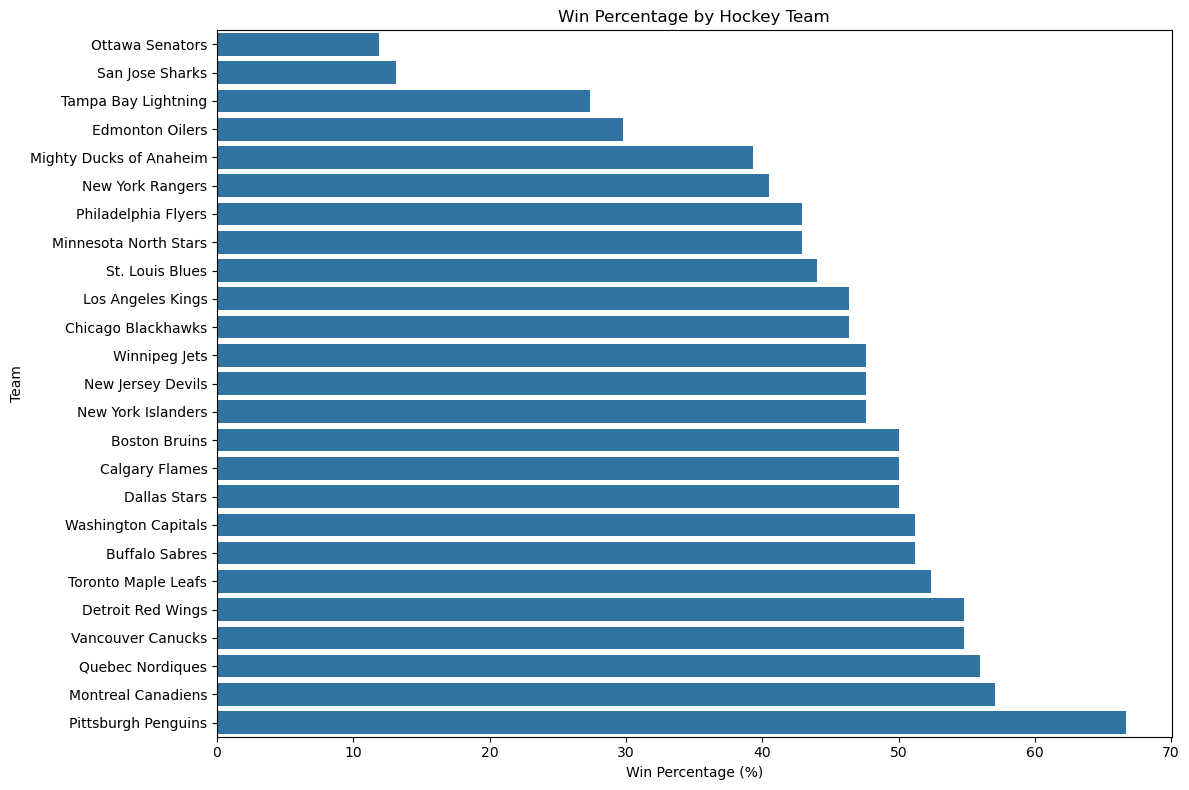

In [28]:
plt.figure(figsize=(12, 8))

plot_df = df.sort_values('Win_Pct')

sns.barplot(
    data=plot_df,
    x=plot_df['Win_Pct'] * 100,
    y='Team'
)

plt.title('Win Percentage by Hockey Team')
plt.xlabel('Win Percentage (%)')
plt.ylabel('Team')

plt.tight_layout()
plt.show()

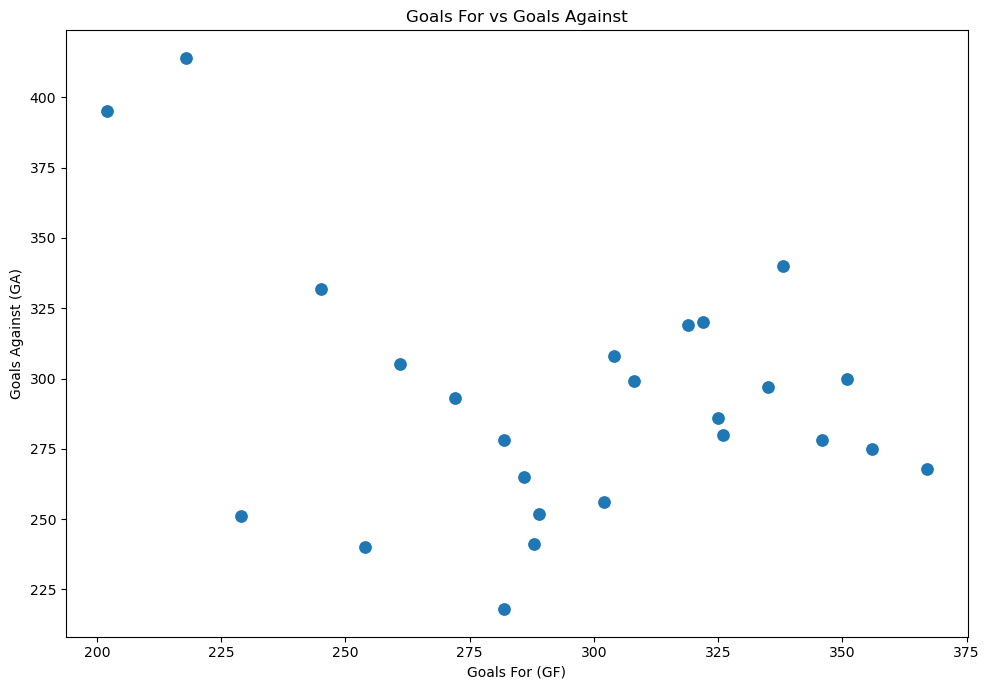

In [29]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x='GF',
    y='GA',
    s=100
)

plt.title('Goals For vs Goals Against')
plt.xlabel('Goals For (GF)')
plt.ylabel('Goals Against (GA)')

plt.tight_layout()
plt.show()

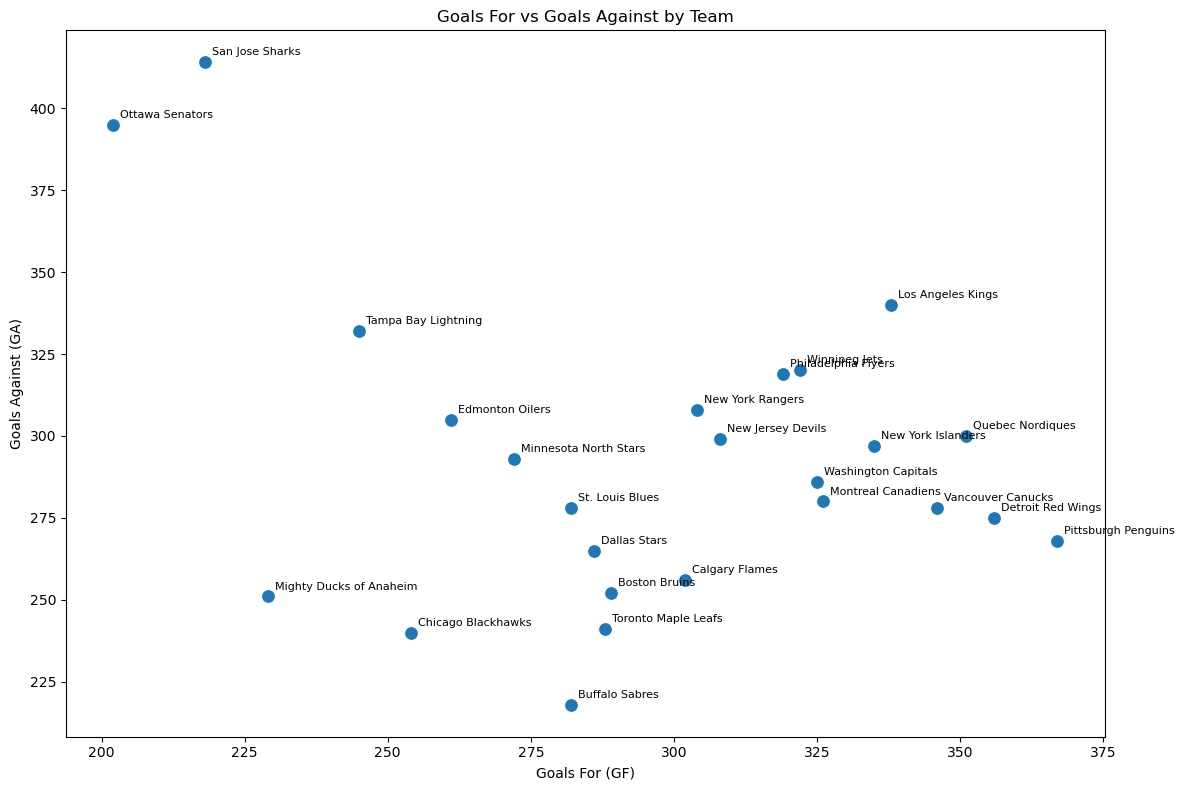

In [30]:
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='GF',
    y='GA',
    s=100
)

for _, row in df.iterrows():
    plt.annotate(
        row['Team'],
        (row['GF'], row['GA']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.title('Goals For vs Goals Against by Team')
plt.xlabel('Goals For (GF)')
plt.ylabel('Goals Against (GA)')

plt.tight_layout()
plt.show()

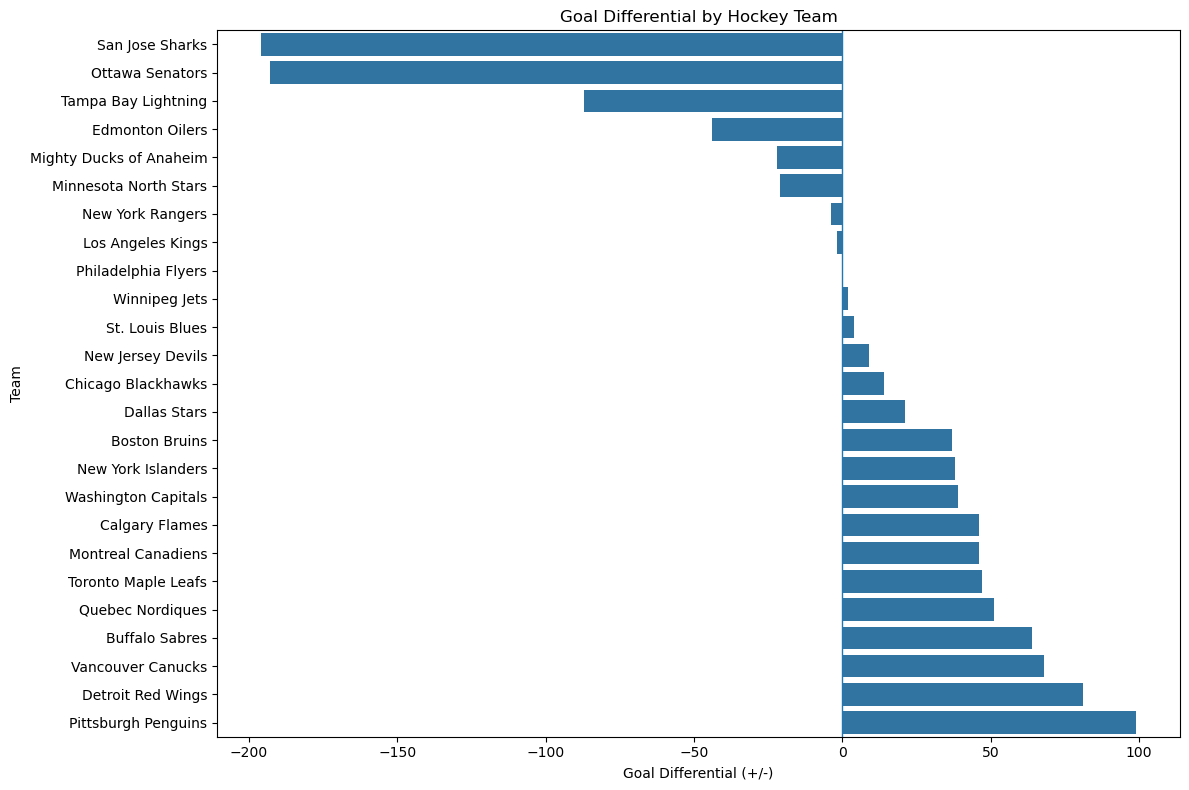

In [31]:
plt.figure(figsize=(12, 8))

plot_df = df.sort_values('Goal_Diff')

sns.barplot(
    data=plot_df,
    x='Goal_Diff',
    y='Team'
)

plt.axvline(0, linewidth=1)

plt.title('Goal Differential by Hockey Team')
plt.xlabel('Goal Differential (+/-)')
plt.ylabel('Team')

plt.tight_layout()
plt.show()

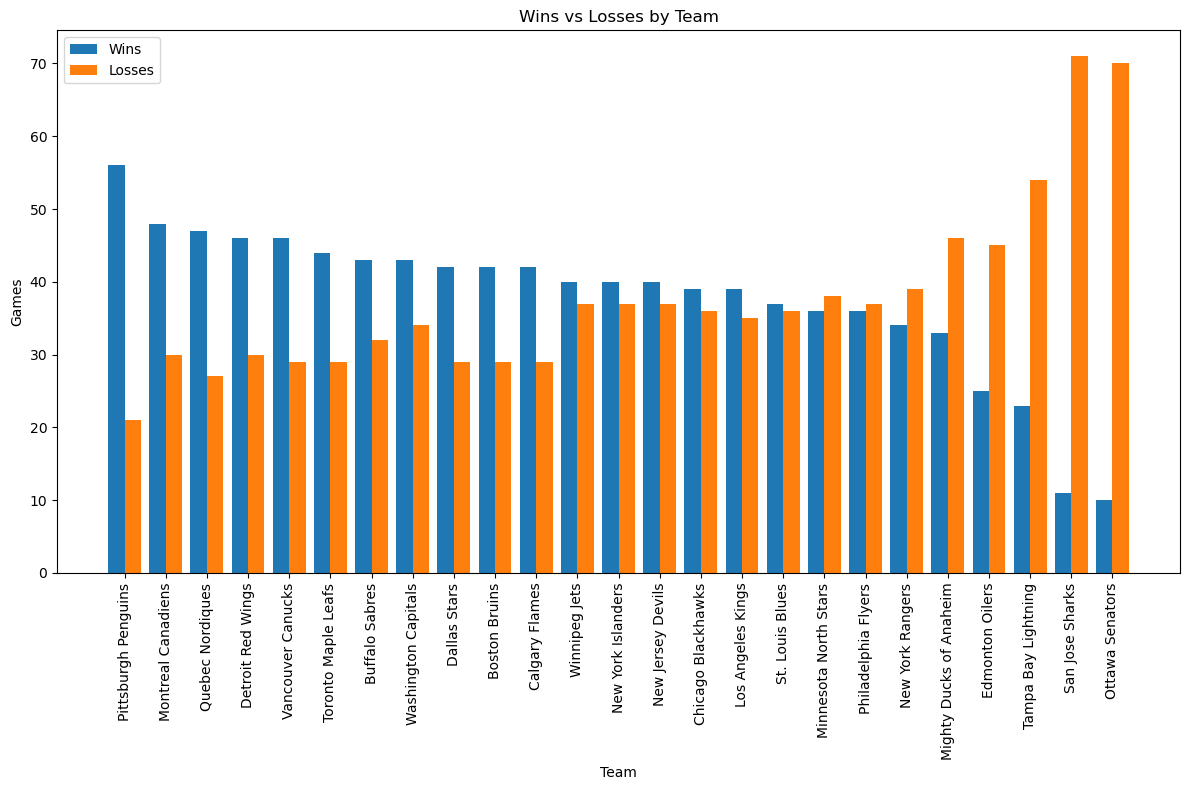

In [32]:
plt.figure(figsize=(12, 8))

plot_df = df.sort_values('Wins', ascending=False)

x = range(len(plot_df))

plt.bar(
    [i - 0.2 for i in x],
    plot_df['Wins'],
    width=0.4,
    label='Wins'
)

plt.bar(
    [i + 0.2 for i in x],
    plot_df['Losses'],
    width=0.4,
    label='Losses'
)

plt.xticks(
    x,
    plot_df['Team'],
    rotation=90
)

plt.xlabel('Team')
plt.ylabel('Games')
plt.title('Wins vs Losses by Team')
plt.legend()

plt.tight_layout()
plt.show()

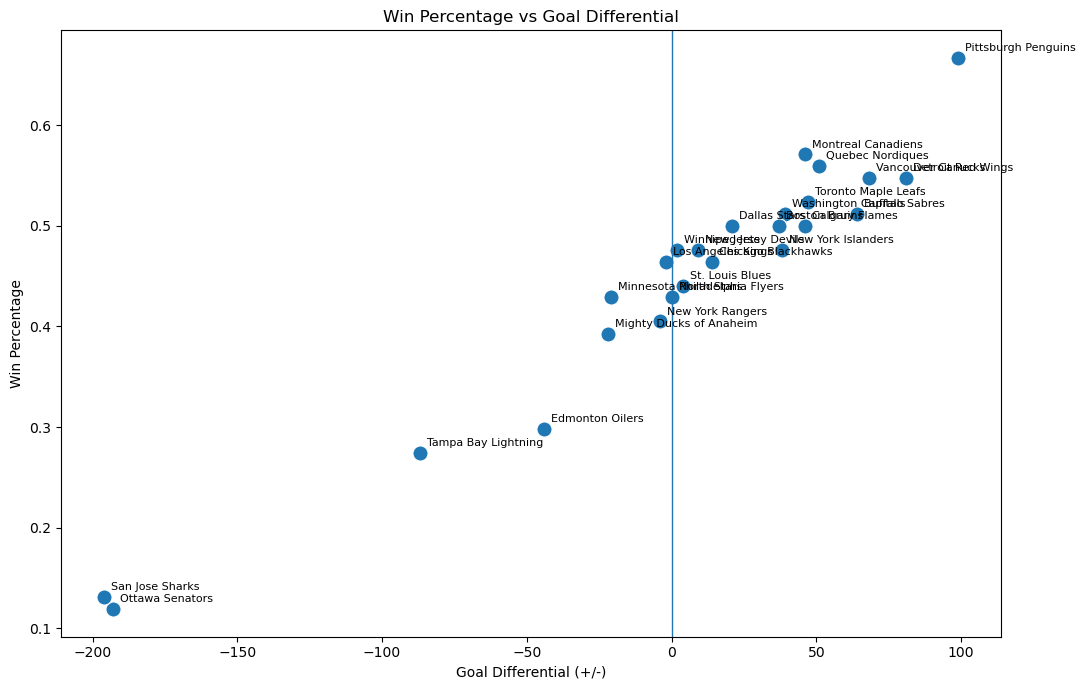

In [33]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x='Goal_Diff',
    y='Win_Pct',
    s=120
)

for _, row in df.iterrows():
    plt.annotate(
        row['Team'],
        (row['Goal_Diff'], row['Win_Pct']),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=8
    )

plt.axvline(0, linewidth=1)

plt.title('Win Percentage vs Goal Differential')
plt.xlabel('Goal Differential (+/-)')
plt.ylabel('Win Percentage')

plt.tight_layout()
plt.show()

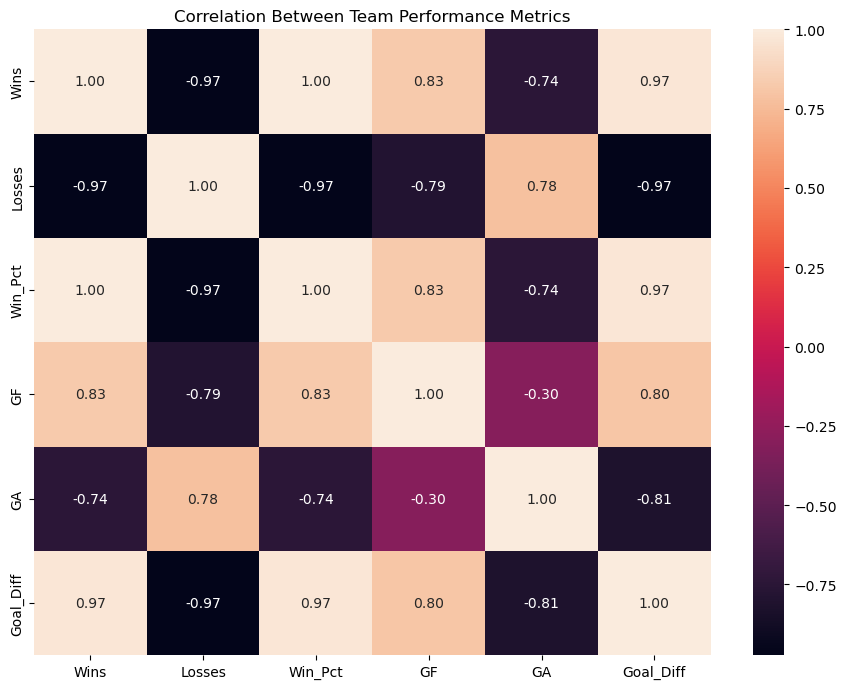

In [34]:
numeric_cols = [
    'Wins',
    'Losses',
    'Win_Pct',
    'GF',
    'GA',
    'Goal_Diff'
]

correlation = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f'
)

plt.title('Correlation Between Team Performance Metrics')

plt.tight_layout()
plt.show()

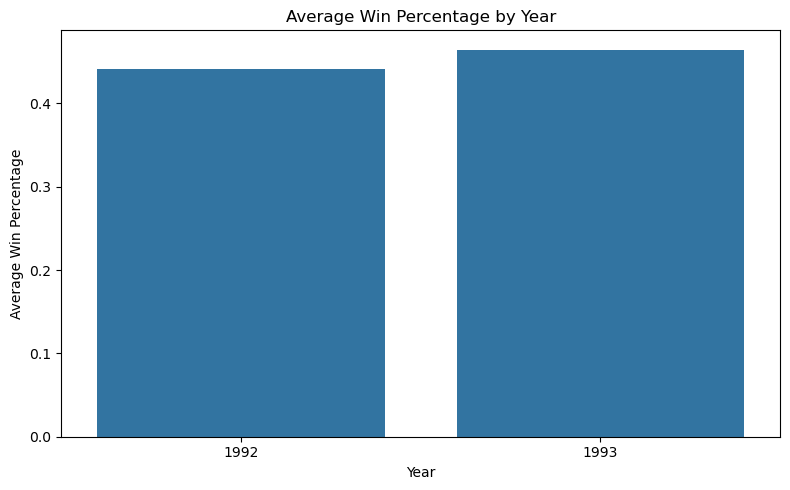

In [35]:
year_win_pct = df.groupby('Year')['Win_Pct'].mean()

plt.figure(figsize=(8, 5))

sns.barplot(
    x=year_win_pct.index,
    y=year_win_pct.values
)

plt.title('Average Win Percentage by Year')
plt.xlabel('Year')
plt.ylabel('Average Win Percentage')

plt.tight_layout()
plt.show()

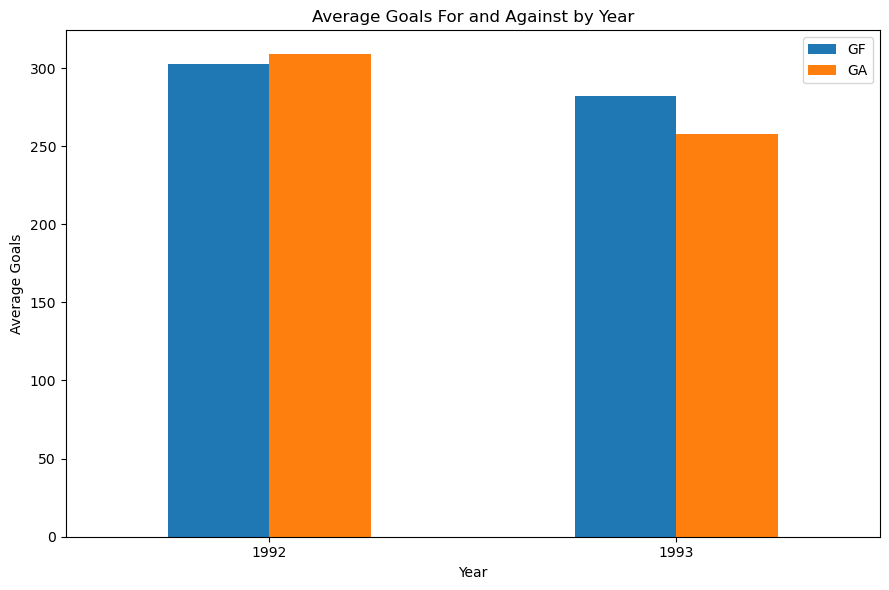

In [36]:
year_goals = df.groupby('Year')[['GF', 'GA']].mean()

year_goals.plot(
    kind='bar',
    figsize=(9, 6)
)

plt.title('Average Goals For and Against by Year')
plt.xlabel('Year')
plt.ylabel('Average Goals')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()